# `load_matches` demo: Opta, StatsBomb, IMPECT

This notebook exercises the unified loading entry point,
`load_matches(source, provider=..., type=...)`, against three real data
sources. Every call takes the exact same two keywords regardless of
provider or scope:

- `provider`: `"opta"` (default), `"statsbomb"`, or `"impect"`
- `type`: `"match"` (default, a single file) or `"season"` (a folder of them)

1. **Opta** — the bundled sample match (ships with the repo, always works)
2. **StatsBomb** — one real match file, then a whole season **folder**
3. **IMPECT** — a real season export (one CSV covering many matches already)

Run top to bottom. Cells 2-4 (StatsBomb/IMPECT) point at files on this
machine — edit the paths in each section's first code cell if yours live
somewhere else. Each section checks the file exists first and skips
cleanly (with a printed note) if it doesn't, so the notebook still runs
end to end even if you only have some of the three sources handy.

See the [Installation](https://waltzinganalytics.readthedocs.io/en/latest/installation.html#input-data)
docs page for the full picture on what each provider supports.

In [1]:
from pathlib import Path

from wa_setpieces import load_matches, set_piece_summary, delivery_locations
from wa_setpieces.viz.plots import plot_delivery_map

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()

## 1. Opta — bundled sample match

`provider="opta"`, `type="match"` — always available, this file ships
with the repo, so this section never needs edits.

In [2]:
opta_events = load_matches(
    REPO_ROOT / "tests" / "data" / "sample_match.json", provider="opta", type="match",
)
print(f"{len(opta_events):,} events, {opta_events['matchId'].nunique()} match")
set_piece_summary(opta_events)

1,613 events, 1 match


,contestantId,set_piece_type,attempts,successful,success_rate,shots,goals
0,cxb4hqite921i36gwrezdts7c,corner,2,1,0.500,0,0
1,cxb4hqite921i36gwrezdts7c,free_kick,12,9,0.750,0,0
2,cxb4hqite921i36gwrezdts7c,goal_kick,8,5,0.625,0,0
3,cxb4hqite921i36gwrezdts7c,kick_off,1,1,1.000,0,0
4,cxb4hqite921i36gwrezdts7c,throw_in,20,16,0.800,0,0
5,f2yd0yzt0om6qhks9gbowu1d6,corner,7,1,0.143,0,0
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,13,9,0.692,0,0
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,4,3,0.750,0,0
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,3,3,1.000,0,0
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,30,27,0.900,0,0


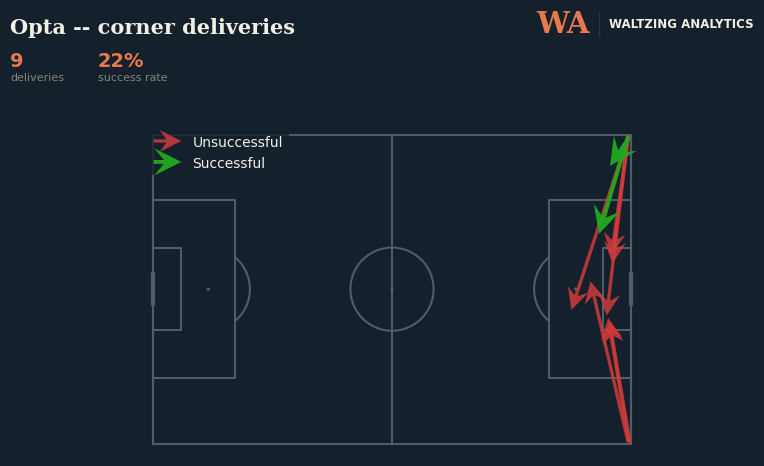

In [3]:
opta_corners = delivery_locations(opta_events, "corner")
plot_delivery_map(opta_corners, title="Opta -- corner deliveries");

## 2. StatsBomb — one real match

`provider="statsbomb"`, `type="match"` — edit `STATSBOMB_MATCH` below to
point at any StatsBomb open-data-shaped events export.

In [4]:
STATSBOMB_MATCH = Path(
    "/Users/marclamberts/Event data/Statsbomb/Liga Pro 2022/"
    "2022-07-23_Orense_vs_Cumbayá_3821378.json"
)

if STATSBOMB_MATCH.exists():
    sb_events = load_matches(STATSBOMB_MATCH, provider="statsbomb", type="match")
    print(f"{len(sb_events):,} events, {sb_events['matchId'].nunique()} match")
    display(set_piece_summary(sb_events))
else:
    sb_events = None
    print(f"Skipping -- file not found: {STATSBOMB_MATCH}")

3,043 events, 1 match


,contestantId,set_piece_type,attempts,successful,success_rate,shots,goals
0,1879,corner,8,3,0.375,1,0
1,1879,free_kick,16,11,0.688,1,0
2,1879,goal_kick,3,2,0.667,0,0
3,1879,kick_off,2,2,1.000,0,0
4,1879,penalty,2,2,1.000,2,1
5,1879,throw_in,17,14,0.824,0,0
6,8621,corner,1,0,0.000,0,0
7,8621,free_kick,19,12,0.632,0,0
8,8621,goal_kick,13,2,0.154,0,0
9,8621,kick_off,4,4,1.000,0,0


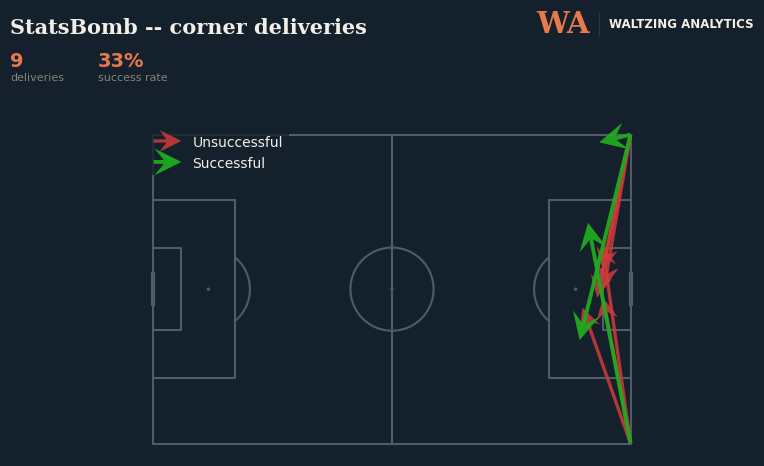

In [5]:
if sb_events is not None:
    sb_corners = delivery_locations(sb_events, "corner")
    plot_delivery_map(sb_corners, title="StatsBomb -- corner deliveries");

## 3. StatsBomb — a whole season folder

`provider="statsbomb"`, `type="season"` — every `*.json` in the folder is
loaded and combined into one events frame, each tagged with its own
filename as `matchId`. On a ~240-match season folder this takes well
under a minute. A non-event sidecar file of the same extension (a
`matches.json`/`competitions.json` StatsBomb ships alongside the actual
match files, say) is skipped with a warning rather than corrupting the
combined frame or aborting the whole folder.

In [6]:
STATSBOMB_SEASON_DIR = Path("/Users/marclamberts/Event data/Statsbomb/Liga Pro 2022")

if STATSBOMB_SEASON_DIR.is_dir():
    season_events = load_matches(STATSBOMB_SEASON_DIR, provider="statsbomb", type="season")
    print(f"{len(season_events):,} events across {season_events['matchId'].nunique()} matches")
else:
    season_events = None
    print(f"Skipping -- folder not found: {STATSBOMB_SEASON_DIR}")

699,030 events across 240 matches


/Users/marclamberts/Documents/GitHub/waltzinganalytics/src/wa_setpieces/core/loader.py:363: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)


In [7]:
if season_events is not None:
    from wa_setpieces import SeasonDataset

    season = SeasonDataset(season_events)
    display(season.summary().head(10))

,contestantId,set_piece_type,matches,attempts,successful,shots,goals,success_rate,attempts_per_match
0,1879,corner,30,147,59,29,4,0.401,4.90
1,1879,free_kick,30,485,363,20,2,0.748,16.17
2,1879,goal_kick,30,224,153,0,0,0.683,7.47
3,1879,kick_off,30,60,59,0,0,0.983,2.00
4,1879,penalty,8,11,11,11,6,1.000,1.38
5,1879,throw_in,30,591,451,0,0,0.763,19.70
6,1904,corner,30,181,80,37,0,0.442,6.03
7,1904,free_kick,30,452,351,13,0,0.777,15.07
8,1904,goal_kick,30,197,160,0,0,0.812,6.57
9,1904,kick_off,30,58,58,0,0,1.000,1.93


## 4. IMPECT — a real season export

`provider="impect"`, `type="match"` — one file, but unlike Opta/StatsBomb
(one file per match), a single IMPECT CSV commonly covers **many
matches already**: `matchId` comes from the export's own `match_id`
column, not the filename.

In [8]:
IMPECT_CSV = Path(
    "/Users/marclamberts/Event data/data/providers/IMPECT/IMPECT_events_iteration_2128.csv"
)

if IMPECT_CSV.exists():
    impect_events = load_matches(IMPECT_CSV, provider="impect", type="match")
    print(f"{len(impect_events):,} events across {impect_events['matchId'].nunique()} matches")
    display(set_piece_summary(impect_events).head(10))
else:
    impect_events = None
    print(f"Skipping -- file not found: {IMPECT_CSV}")

52,938 events across 20 matches


,contestantId,set_piece_type,attempts,successful,success_rate,shots,goals
0,1708,corner,12,5,0.417,4,1
1,1708,free_kick,22,10,0.455,2,0
2,1708,goal_kick,17,14,0.824,0,0
3,1708,kick_off,5,5,1.000,0,0
4,1708,throw_in,35,25,0.714,4,0
5,1709,corner,9,0,0.000,3,0
6,1709,free_kick,26,18,0.692,3,0
7,1709,goal_kick,19,13,0.684,0,0
8,1709,kick_off,3,3,1.000,0,0
9,1709,throw_in,40,30,0.750,2,0


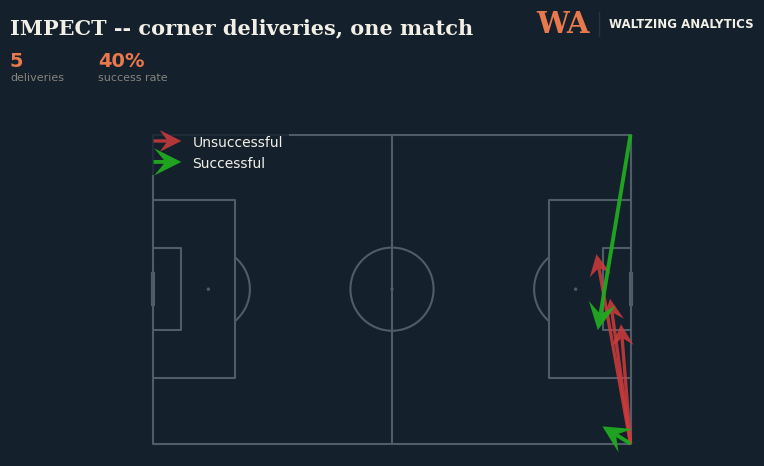

In [9]:
if impect_events is not None:
    one_match = impect_events[impect_events["matchId"] == impect_events["matchId"].iloc[0]]
    impect_corners = delivery_locations(one_match, "corner")
    plot_delivery_map(impect_corners, title="IMPECT -- corner deliveries, one match");

## Where next

- [Installation → Input data](https://waltzinganalytics.readthedocs.io/en/latest/installation.html#input-data) --
  the full picture on what each provider supports and what's mapped.
- `wa_setpieces/providers/statsbomb.py` and `wa_setpieces/providers/impect.py` --
  module docstrings document exactly what's faithfully converted per provider.
- [Gallery](https://waltzinganalytics.readthedocs.io/en/latest/gallery/index.html) --
  every plot this package makes, with the source that made it.